In [1]:
# import
import pandas as pd
import numpy as np
import sqlite3 as sql

In [2]:
# Define the path to raw data file

file_path = '../raw_data/JC-202501-citibike-tripdata.csv'

# Chunk size for reading the CSV file
chunk_size = 1000000
df_chunks = pd.read_csv(file_path, chunksize=chunk_size)
# Initialize an empty list to store DataFrames

cleaned_chunks = []

# Iterate over each chunk and process it

for chunk in df_chunks:
    print("chunk info: ", chunk.info())
    print("chunk shape: ", chunk.shape)
    print("chunk null values: ", chunk.isnull().sum())
    print(chunk.head())
    # We have missing values in the columns 'end station id' , 'end station name' , ' end station latitude' , 'end station longitude' , 'birth year'
    # We will drop the rows with missing values in these columns

    chunk = chunk.dropna(subset=['end station id', 'end station name', 'end station latitude', 'end station longitude', 'birth year'])

    # we will transform start time  and end time to datetime format

    chunk['starttime'] = pd.to_datetime(chunk['starttime'],)
    chunk['stoptime'] = pd.to_datetime(chunk['stoptime'],)
    
    # convert end station name to string
    chunk['end station name'] = chunk['end station name'].astype(str)
    chunk['start station name'] = chunk['start station name'].astype(str)

    cleaned_chunks.append(chunk)

# Concatenate all cleaned chunks into a single DataFrame
df = pd.concat(cleaned_chunks, ignore_index=True)

# Display the cleaned DataFrame information
print("Cleaned DataFrame info: ", df.info())
print("Cleaned DataFrame shape: ", df.shape)
print("Cleaned DataFrame null values: ", df.isnull().sum())
print(df.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577703 entries, 0 to 577702
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   tripduration             577703 non-null  int64  
 1   starttime                577703 non-null  object 
 2   stoptime                 577703 non-null  object 
 3   start station id         577703 non-null  int64  
 4   start station name       577703 non-null  object 
 5   start station latitude   577703 non-null  float64
 6   start station longitude  577703 non-null  float64
 7   end station id           559644 non-null  float64
 8   end station name         559644 non-null  object 
 9   end station latitude     559644 non-null  float64
 10  end station longitude    559644 non-null  float64
 11  bikeid                   577703 non-null  int64  
 12  usertype                 577703 non-null  object 
 13  birth year               337382 non-null  float64
 14  gend

In [3]:
# Save cleaned data to CSV for reference
df.to_csv('../output/cleaned_data.csv', index=False)

In [4]:
# More data cleaning and transformation can be done here if needed

df['trip_duration_min'] = (df['stoptime'] - df['starttime']).dt.total_seconds() / 60.0  # in minutes

# Remove trips with negative or unrealistic durations (>24 hours)
df = df[(df['trip_duration_min'] > 0) & (df['trip_duration_min'] < 1440)]

# Standardize station names (e.g., remove extra spaces)
df['start station name'] = df['start station name'].str.strip()
df['end station name'] = df['end station name'].str.strip()

# Feature engineering
# Extracting year, month, day, hour from starttime
df['start_year'] = df['starttime'].dt.year
df['start_month'] = df['starttime'].dt.month
df['start_day'] = df['starttime'].dt.day
df['start_hour'] = df['starttime'].dt.hour
df['start_minute'] = df['starttime'].dt.minute
df['start_dayofweek'] = df['starttime'].dt.day_name()  # Monday=0, Sunday=6


# Extracting year, month, day, hour from stoptime
df['stop_year'] = df['stoptime'].dt.year
df['stop_month'] = df['stoptime'].dt.month
df['stop_day'] = df['stoptime'].dt.day
df['stop_hour'] = df['stoptime'].dt.hour
df['stop_minute'] = df['stoptime'].dt.minute
df['stop_dayofweek'] = df['stoptime'].dt.day_name()  # Monday=0, Sunday=6

# Trip per station

station_trips = df.groupby('start station name').size().reset_index(name='trip_count')

# Save transformed data
df.to_csv('../output/transformed_data.csv', index=False)
station_trips.to_csv('../output/station_trips.csv', index=False)




In [5]:
# Migrate to SQLite database

# Connect to SQLite
import sqlite3


conn = sqlite3.connect('../output/citi_bike.db')
cursor = conn.cursor()

# Create table for raw trip data
cursor.execute('''
    CREATE TABLE IF NOT EXISTS trips (
        ride_id TEXT,
        rideable_type TEXT,
        started_at DATETIME,
        ended_at DATETIME,
        start_station_name TEXT,
        end_station_name TEXT,
        start_lat FLOAT,
        start_lng FLOAT,
        end_lat FLOAT,
        end_lng FLOAT,
        member_casual TEXT,
        trip_duration_min FLOAT,
        day_of_week TEXT,
        hour INTEGER,
        distance_km FLOAT
    )
''')

# Load raw data
df.to_sql('trips', conn, if_exists='replace', index=False)

# Create table for aggregated data (station trips)
cursor.execute('''
    CREATE TABLE IF NOT EXISTS station_trips (
        start_station_name TEXT,
        trip_count INTEGER
    )
''')

# Load aggregated data
station_trips.to_sql('station_trips', conn, if_exists='replace', index=False)

# Verify load
query = "SELECT * FROM trips LIMIT 5"
print(pd.read_sql_query(query, conn))

query = "SELECT * FROM station_trips LIMIT 5"
print(pd.read_sql_query(query, conn))

# Commit and close
conn.commit()
conn.close()

   tripduration            starttime             stoptime  start station id  \
0           695  2013-06-01 00:00:01  2013-06-01 00:11:36               444   
1           693  2013-06-01 00:00:08  2013-06-01 00:11:41               444   
2           123  2013-06-01 00:01:04  2013-06-01 00:03:07               475   
3          1521  2013-06-01 00:01:22  2013-06-01 00:26:43              2008   
4          2057  2013-06-01 00:02:33  2013-06-01 00:36:50               285   

      start station name  start station latitude  start station longitude  \
0     Broadway & W 24 St               40.742354               -73.989151   
1     Broadway & W 24 St               40.742354               -73.989151   
2    E 15 St & Irving Pl               40.735243               -73.987586   
3  Little West St & 1 Pl               40.705693               -74.016777   
4     Broadway & E 14 St               40.734546               -73.990741   

   end station id     end station name  end station latitude  

In [9]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('../output/citi_bike.db')
query = '''
    SELECT [start station name], trip_count
    FROM station_trips
    ORDER BY trip_count DESC
    LIMIT 10
'''
top_stations = pd.read_sql_query(query, conn)
print(top_stations)

query = '''
    SELECT start_hour, COUNT(*) as trip_count
    FROM trips
    GROUP BY start_hour
    ORDER BY start_hour
'''
hourly_usage = pd.read_sql_query(query, conn)
print(hourly_usage)

      start station name  trip_count
0     E 17 St & Broadway        3362
1     Broadway & E 14 St        3119
2       W 20 St & 11 Ave        3013
3  Lafayette St & E 8 St        2731
4      8 Ave & W 31 St N        2667
5     Broadway & W 58 St        2656
6     Broadway & E 22 St        2610
7     Broadway & W 24 St        2574
8  Pershing Square North        2435
9   E 24 St & Park Ave S        2307
    start_hour  trip_count
0            0        3746
1            1        1976
2            2        1156
3            3         620
4            4         542
5            5        1306
6            6        5432
7            7       12244
8            8       24421
9            9       20458
10          10       13465
11          11       14415
12          12       18163
13          13       19115
14          14       18086
15          15       17868
16          16       20445
17          17       30911
18          18       32241
19          19       24545
20          20       17898

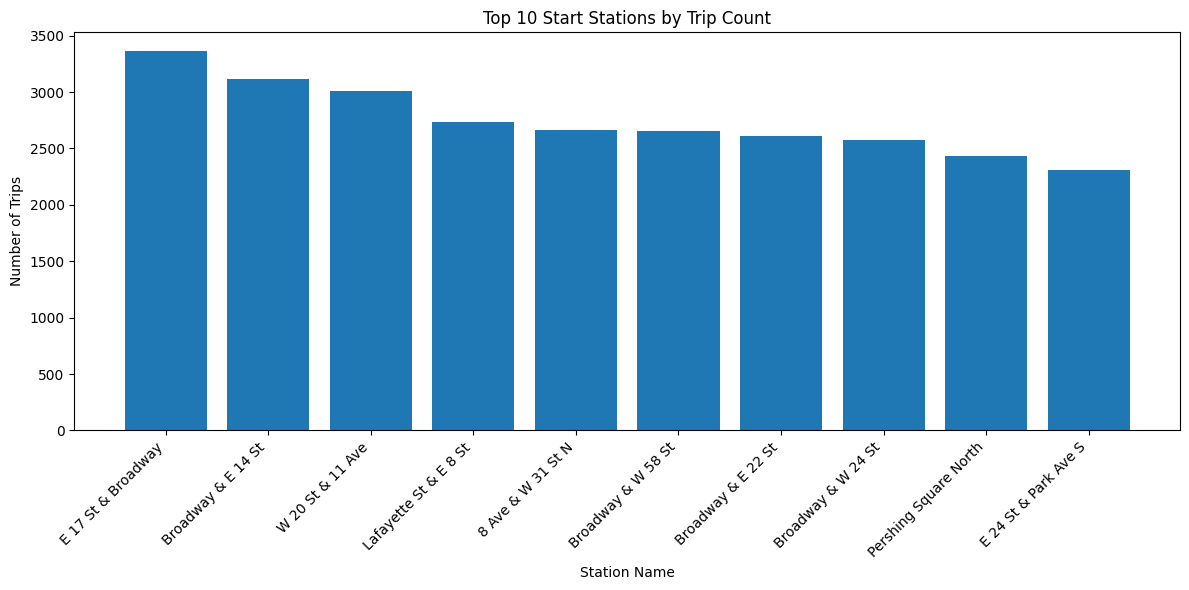

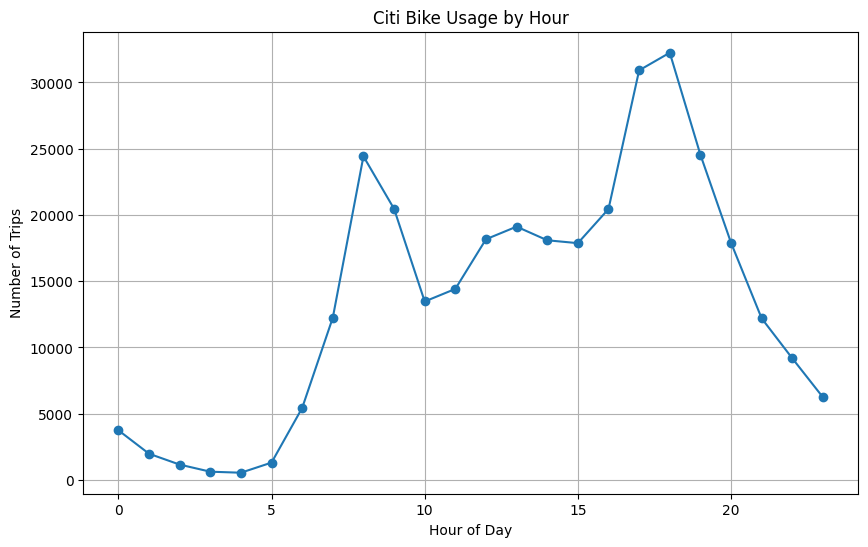

In [13]:
## Visualtization

import matplotlib.pyplot as plt

## Bar Chart: Top Stations:

plt.figure(figsize=(12, 6))
plt.bar(top_stations['start station name'], top_stations['trip_count'])
plt.xlabel('Station Name')
plt.ylabel('Number of Trips')
plt.title('Top 10 Start Stations by Trip Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../output/visualizations/top_stations.png')
plt.show()


# Line Chart: Hourly Usage

plt.figure(figsize=(10, 6))
plt.plot(hourly_usage['start_hour'], hourly_usage['trip_count'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Citi Bike Usage by Hour')
plt.grid(True)
plt.savefig('../output/visualizations/hourly_usage.png')
plt.show()